In [ ]:
 #■■ Decision Tree: Fit, Inspect, Predict ■■
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Load iris dataset: 150 flowers, 4 features, 3 species
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# ■■ Train a shallow tree (depth=2 so it's tiny and readable) ■■
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
print(f'Train accuracy: {tree.score(X_train, y_train):.2%}')
print(f'Test accuracy: {tree.score(X_test, y_test):.2%}')

Train accuracy: 95.00%
Test accuracy: 96.67%


In [ ]:
# ■■ Text view: see the if-else rules as text ■■
print(export_text(tree, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- class: 2



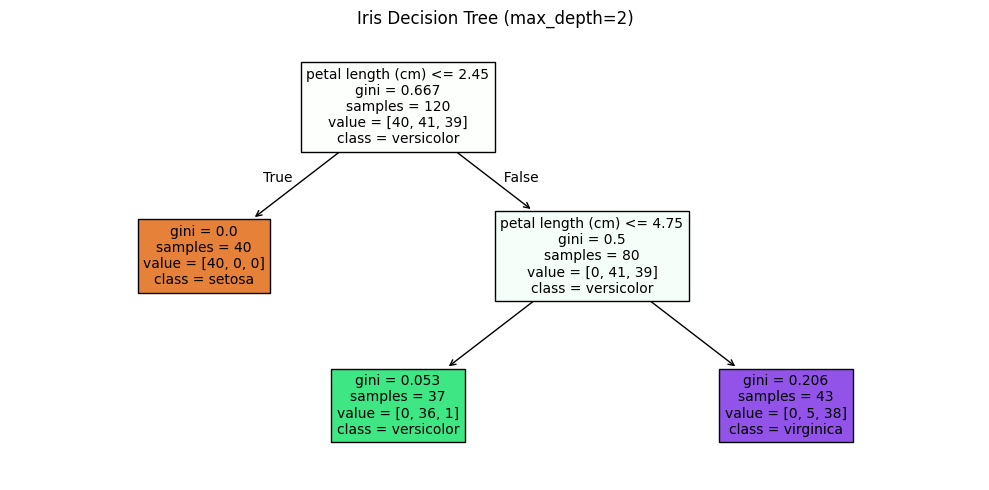

In [ ]:
# ■■ Visual view ■■
plt.figure(figsize=(10, 5))
plot_tree(tree, feature_names=iris.feature_names,
class_names=iris.target_names,
filled=True, rounded=False, fontsize=10)
plt.title('Iris Decision Tree (max_depth=2)'); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Predict a single new flower ■■
new_flower = [[5.1, 3.5, 1.4, 0.2]] # sepal_len, sepal_wid, petal_len, petal_wid
pred = tree.predict(new_flower)[0]
print(f'Predicted species: {iris.target_names[pred]}')
print(f'Probabilities : {tree.predict_proba(new_flower)[0]}')

Predicted species: setosa
Probabilities : [1. 0. 0.]


In [ ]:
# ■■ Gini Impurity: Manual + sklearn ■■
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# ■■ Part 1: Manual Gini calculation ■■
def gini_impurity(labels):
    """Calculate Gini impurity for a list of class labels."""
    labels = np.array(labels)
    n = len(labels)
    if n == 0: return 0
    classes = np.unique(labels)
    gini = 1.0
    for c in classes:
        p = np.sum(labels == c) / n # proportion of class c
        gini -= p ** 2
    return gini

In [ ]:
# Test different node compositions
print('Pure node (all same) :', gini_impurity([1,1,1,1,1])) # 0.00
print('50-50 split :', gini_impurity([0,0,0,1,1,1])) # 0.50
print('70-30 split :', gini_impurity([0,0,0,0,0,0,0,1,1,1])) # 0.42
print('90-10 split :', gini_impurity([0]*9 + [1])) # 0.18

Pure node (all same) : 0.0
50-50 split : 0.5
70-30 split : 0.42000000000000004
90-10 split : 0.17999999999999994


In [ ]:
# ■■ Part 2: Weighted Gini for a split ■■
def weighted_gini(left_labels, right_labels):
    """Gini after a split — weighted by group size."""
    n_total = len(left_labels) + len(right_labels)
    w_left = len(left_labels) / n_total
    w_right = len(right_labels) / n_total
    return w_left * gini_impurity(left_labels) + w_right * gini_impurity(right_labels)

In [ ]:
# Two possible splits on a feature — which is better?
# Split A: Glucose <= 120 vs Glucose > 120
left_A = [0,0,0,0,1] # Glucose <= 120: 4 healthy, 1 diabetic
right_A = [0,1,1,1,1] # Glucose > 120: 1 healthy, 4 diabetic

In [ ]:
# Split B: Age <= 30 vs Age > 30
left_B = [0,0,1,1,0] # Age <= 30: mixed
right_B = [0,1,0,1,1] # Age > 30: mixed

In [ ]:
print(f'Weighted Gini — Glucose split: {weighted_gini(left_A, right_A):.3f}')
print(f'Weighted Gini — Age split : {weighted_gini(left_B, right_B):.3f}')
print('Tree picks the split with LOWER weighted Gini → Glucose split is better!')

Weighted Gini — Glucose split: 0.320
Weighted Gini — Age split : 0.480
Tree picks the split with LOWER weighted Gini → Glucose split is better!


In [ ]:
# ■■ Part 3: See sklearn report the Gini per node ■■
from sklearn.datasets import make_classification
from sklearn.tree import export_text
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)
# export_text shows 'gini' value at each node
print(export_text(tree, feature_names=['F1','F2','F3','F4']))
# Each node shows: feature threshold | gini | samples | distribution

|--- F1 <= -0.15
|   |--- F3 <= -0.44
|   |   |--- class: 0
|   |--- F3 >  -0.44
|   |   |--- class: 0
|--- F1 >  -0.15
|   |--- F3 <= 0.63
|   |   |--- class: 1
|   |--- F3 >  0.63
|   |   |--- class: 0



**OVERFITTING**

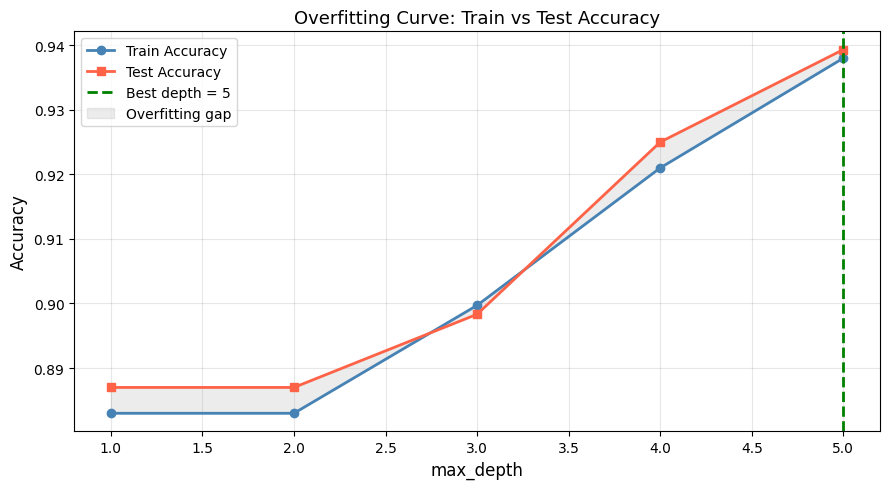

Best test accuracy 93.93% at depth=5


In [ ]:
# ■■ Depth Tuning: Visualise the Overfitting Curve ■■
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=10000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
depths = range(1, 6)
train_acc, test_acc = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))
best_depth = depths[test_acc.index(max(test_acc))]
plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato', lw=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths,
                 train_acc, test_acc,
                 alpha=0.15, color='gray', label='Overfitting gap')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting Curve: Train vs Test Accuracy', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# INSIGHT: Train acc always increases → tree memorises more
# Test acc peaks then falls → past the peak = overfitting
print(f'Best test accuracy {max(test_acc):.2%} at depth={best_depth}')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
configs = [
    {'max_depth':None},
    {'max_depth':5},
    {'max_depth':5, 'min_samples_split':10},
    {'max_depth':3,'min_samples_leaf': 5},
    {'max_depth':4, 'max_features': 'sqrt'},
]
print(f'{'Config':45s}{'CV Score(mean±std)':20s}')
print('-' * 60)
for config in configs:
    tree = DecisionTreeClassifier(**config, random_state=42)
    scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
    print(f'{str(config):45s}{scores.mean():.3f} ± {scores.std():.3f}')


Config                                       CV Score(mean±std)  
------------------------------------------------------------
{'max_depth': None}                          0.900 ± 0.004
{'max_depth': 5}                             0.926 ± 0.008
{'max_depth': 5, 'min_samples_split': 10}    0.926 ± 0.008
{'max_depth': 3, 'min_samples_leaf': 5}      0.898 ± 0.006
{'max_depth': 4, 'max_features': 'sqrt'}     0.888 ± 0.016
